# **3.0 Data Processing**

### **3.1 Importing Libraries**

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### **3.2 Loading the data**

In [ ]:
# Importing Data
df = sns.load_dataset('tips')

### **3.3 Having a look at data set**

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.shape

(244, 7)

In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# **7.0 Model Building**

### **7.1 Label Encoding the categorical columns**

In [ ]:
sex_le = LabelEncoder()
smoker_le = LabelEncoder()
day_le = LabelEncoder()
time_le = LabelEncoder()


df['sex'] = sex_le.fit_transform(df['sex'])
df['smoker'] = smoker_le.fit_transform(df['smoker'])
df['day'] = day_le.fit_transform(df['day'])
df['time'] = time_le.fit_transform(df['time'])

### **7.2 Spliting the data into X and y**

In [ ]:
# Split the data into X and y
X = df[['total_bill']]
y = df['tip']

### **7.3 Scaling the data**

In [ ]:
# Scaling the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

### **7.4 Spliting the data into train and test sets**

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=12)

### **7.5 Intializing, Training and Evaluating the model**

In [ ]:
# Building the model
model = LinearRegression()

# Training the model
model.fit(X_train, y_train)

# Evaluating the model
y_pred = model.predict(X_test)

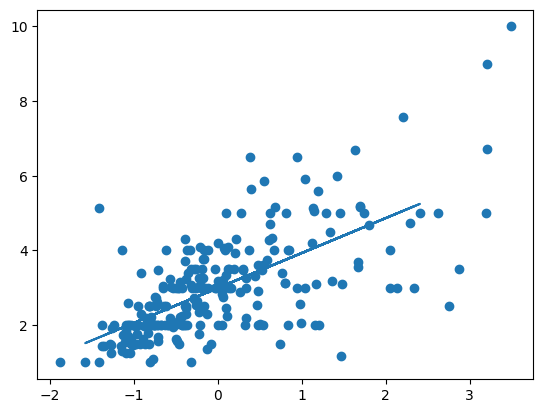

In [ ]:
plt.scatter(X,y)
plt.plot(X_test,y_pred)
plt.show()

### **7.6 Checking the model Score**

In [ ]:
# checking the scores of the model

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test, y_pred)

print('MAE is : ',mae)
print('MSE is : ',mse)
print('R2 is  : ',r2)

MAE is :  0.7149245966062187
MSE is :  1.0448379583727099
R2 is  :  0.44843197141776103


In [ ]:
model.coef_

array([0.93526648])

In [ ]:
model.intercept_

np.float64(2.995494489417593)

Epoch 1, Intercept: 3.0303999999999993
Epoch 2, Intercept: 2.873648000000003
Epoch 3, Intercept: 3.481845759999989
Epoch 4, Intercept: 1.122038451200043
Epoch 5, Intercept: 10.278090809343833


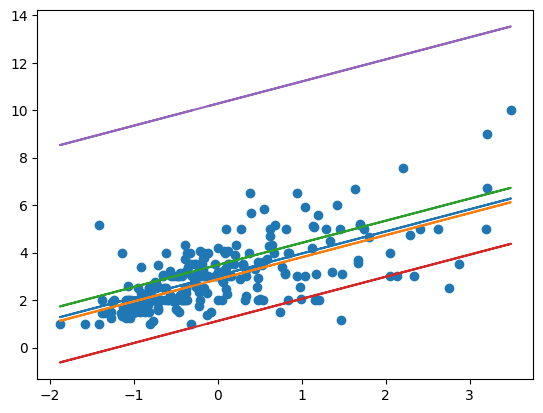

In [ ]:
b = 2.99
m = 0.93
lr = 0.01

epochs = 5

X_single_feature = X[:, 0]

for i in range(epochs):
  # Calculate loss slope with the single feature
  loss_slope = -2 * np.sum(y - m * X_single_feature - b)
  step_size = loss_slope * lr
  b = b - step_size
  print(f"Epoch {i+1}, Intercept: {b}")

  y_pred_gd = m * X_single_feature + b

  plt.plot( X_single_feature,y_pred_gd)

plt.scatter( X_single_feature,y)